## GMM Model Evaluation

In [84]:
from preprocessing import preprocess
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from scipy.stats import norm
from sklearn.decomposition import PCA
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score

X_scaled, scaler, df, feature_names = preprocess(return_df=True)
df_numeric = df[feature_names]

/Users/megan/Documents/Year 3/Games Project/Games Project Unity/ChronoQuest1/Assets/Scripts/Final Boss ML/preprocessing.py:28: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["dash_rate"] = df["dash_count"] / df["session_duration_seconds"]
/Users/megan/Documents/Year 3/Games Project/Games Project Unity/ChronoQuest1/Assets/Scripts/Final Boss ML/preprocessing.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["jump_rate"] = (df["jump_count"] + df["wall_jump_count"] + df["double_jump_count"]) / df["sessi

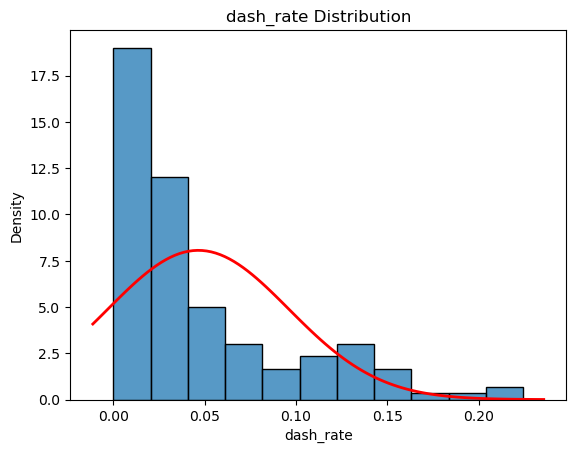

In [85]:
# --- histogram visualisation of dash feature ---
dash_feature = "dash_rate"
data = df_numeric[dash_feature] 

sns.histplot(data, kde=False, stat='density')
mu, std = norm.fit(data)

xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)
p = norm.pdf(x, mu, std)

plt.plot(x, p, 'r', linewidth=2)
plt.title(f"{dash_feature} Distribution")
plt.show()

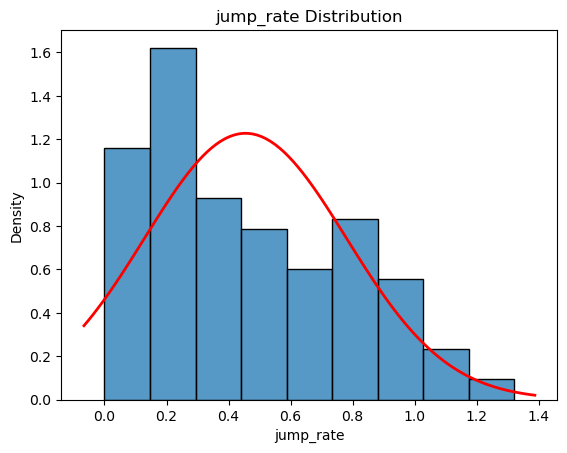

In [86]:
# --- histogram visualisation of jump feature ---
jump_feature = "jump_rate"
jump_data = df_numeric[jump_feature]

sns.histplot(jump_data, kde=False, stat='density')
mu, std = norm.fit(jump_data)

xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)
p = norm.pdf(x, mu, std)

plt.plot(x, p, 'r', linewidth=2)
plt.title(f"{jump_feature} Distribution")
plt.show()

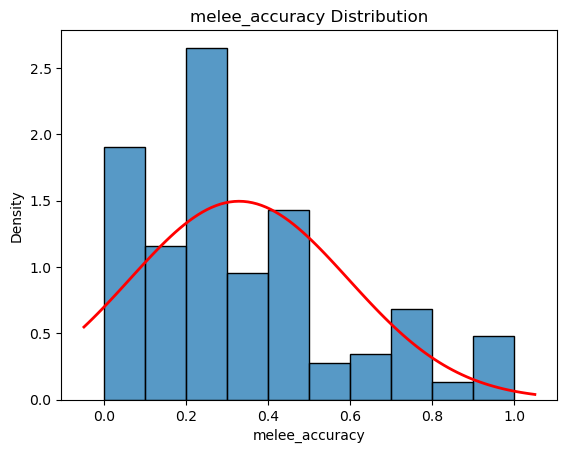

In [87]:
# --- melee feature histogram ---
melee_features = "melee_accuracy"
melee_data = df_numeric[melee_features]

sns.histplot(melee_data, kde=False, stat='density')
mu, std = norm.fit(melee_data)

xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)
p = norm.pdf(x, mu, std)

plt.plot(x, p, 'r', linewidth=2)
plt.title(f"{melee_features} Distribution")
plt.show()

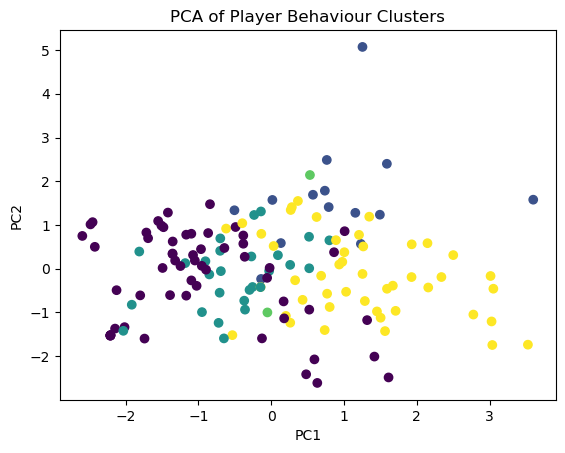

In [88]:
# --- pca for visualisation ---
gmm = GaussianMixture(n_components=5, random_state=42)
labels = gmm.fit_predict(X_scaled)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels)
plt.title("PCA of Player Behaviour Clusters")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

In [ ]:
# TODO umap

In [ ]:
# TODO t-sne 

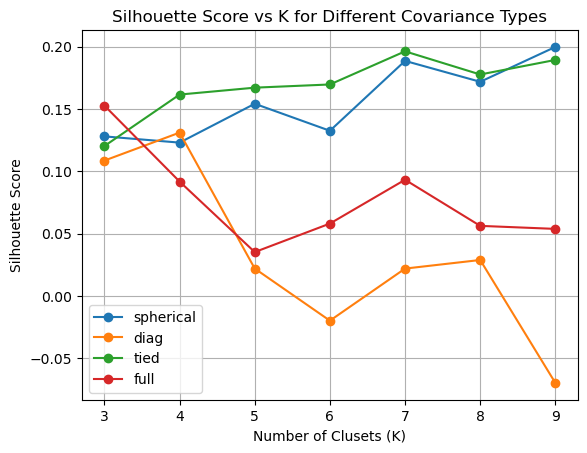

In [89]:
# --- plot for covariance, k and silhouette score ---
# calculating values
results = []

for cov in ["spherical", "diag", "tied", "full"]:
    for k in range(3, 10):
        gmm = GaussianMixture(n_components=k, covariance_type=cov, random_state=42)
        labels = gmm.fit_predict(X_scaled)
        score = silhouette_score(X_scaled, labels)
        
        results.append({
            "covariance": cov, 
            "k": k,
            "silhouette": score
        })

df_results = pd.DataFrame(results)

# plotting the figure
plt.figure() 

for cov in df_results["covariance"].unique():
    subset = df_results[df_results["covariance"] == cov]
    plt.plot(subset["k"], subset["silhouette"], marker="o", label=cov)

plt.xlabel("Number of Clusets (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score vs K for Different Covariance Types")
plt.legend()
plt.grid()
plt.show()

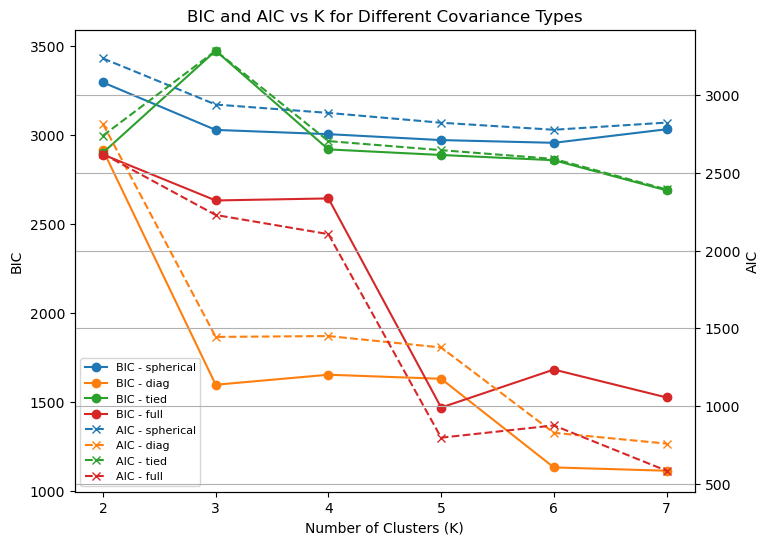

In [90]:
# plots for aic and bic comparison vs K
aic_bic_results = []

for cov in ["spherical", "diag", "tied", "full"]:
    for k in range(2, 8):
        gmm = GaussianMixture(n_components=k, covariance_type=cov, random_state=42)
        gmm.fit(X_scaled)

        labels = gmm.predict(X_scaled)

        aic_bic_results.append({
            "covariance": cov,
            "k": k,
            "silhouette": silhouette_score(X_scaled, labels), 
            "bic": gmm.bic(X_scaled),
            "aic": gmm.aic(X_scaled)
        })

        df_aic_bic_results = pd.DataFrame(aic_bic_results)

# --- plotting dual-axis figure ---
fig, ax1 = plt.subplots(figsize=(8, 6))

for cov in df_aic_bic_results["covariance"].unique():
    subset = df_aic_bic_results[df_aic_bic_results["covariance"] == cov]
    ax1.plot(subset["k"], subset["bic"], marker='o', label=f"BIC - {cov}")

ax1.set_xlabel("Number of Clusters (K)")
ax1.set_ylabel("BIC")

ax2 = ax1.twinx()
for cov in df_aic_bic_results["covariance"].unique():
    subset = df_aic_bic_results[df_aic_bic_results["covariance"] == cov]
    ax2.plot(subset["k"], subset["aic"], linestyle='--', marker='x', label=f"AIC - {cov}")

ax2.set_ylabel("AIC")

plt.title("BIC and AIC vs K for Different Covariance Types")

lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, fontsize=8)
plt.grid()
plt.show()

In [ ]:
# TODO cluster sizes? distances and means? 